K-Means

In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(iris.feature_names)

(150, 4)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print(kmeans_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [5]:
print(kmeans.cluster_centers_)

[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


<function matplotlib.pyplot.show(close=None, block=None)>

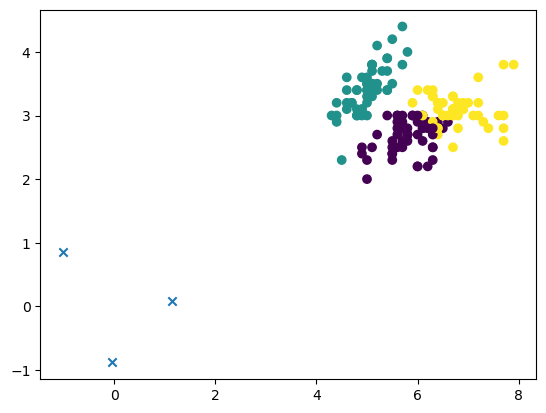

In [6]:
import matplotlib.pyplot as plt

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans_labels
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='x',
)
plt.show

Hierarchical Clustering

In [7]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print(hierarchical_labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 0 0 0 2 0 2 0 2 0 2 2 0 2 0 2 0 2 2 2 2 0 0 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 2 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


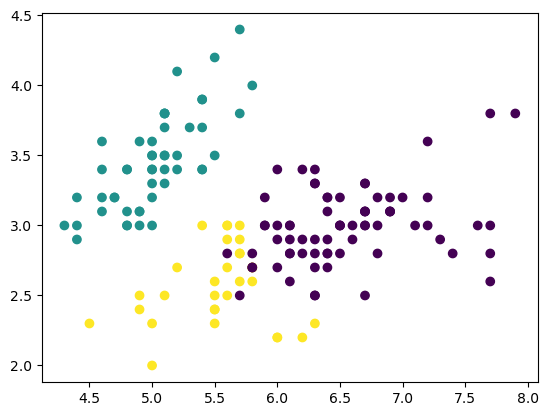

In [8]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=hierarchical_labels
)
plt.show()

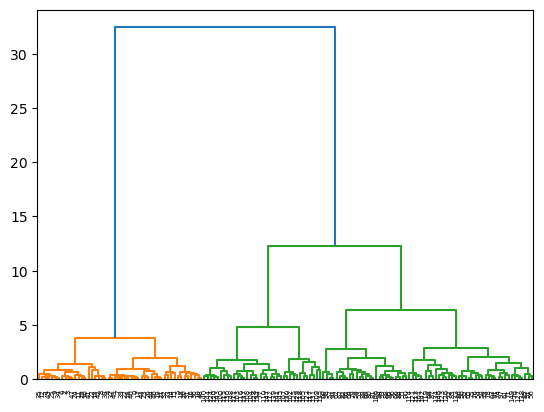

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')

# plt.figure()

dendrogram(Z)

plt.show()

Compare as we have the labels

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y,
    "KMeans": kmeans_labels,
    "Hierarchical": hierarchical_labels
})

print(comparison.head(20))

    Actual  KMeans  Hierarchical
0        0       1             1
1        0       1             1
2        0       1             1
3        0       1             1
4        0       1             1
5        0       1             1
6        0       1             1
7        0       1             1
8        0       1             1
9        0       1             1
10       0       1             1
11       0       1             1
12       0       1             1
13       0       1             1
14       0       1             1
15       0       1             1
16       0       1             1
17       0       1             1
18       0       1             1
19       0       1             1


Silhouette

In [11]:
from sklearn.metrics import silhouette_score

kmeans_sil = silhouette_score(
    X_scaled,
    kmeans_labels
)

hier_sil = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print('k: ', kmeans_sil)
print('hi: ', hier_sil)

k:  0.45994823920518635
hi:  0.4466890410285909


PCA

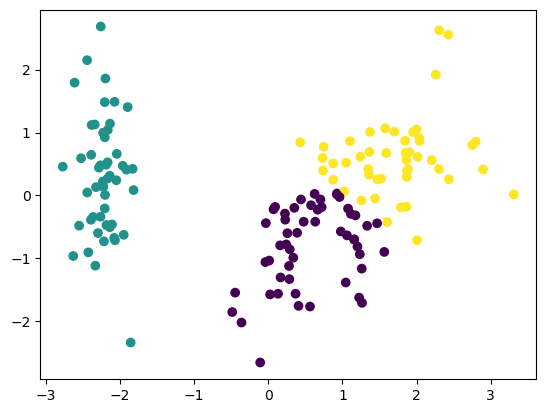

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_pca = pca.fit_transform(X_scaled)

plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=kmeans_labels
)

plt.show()

Elbow Method

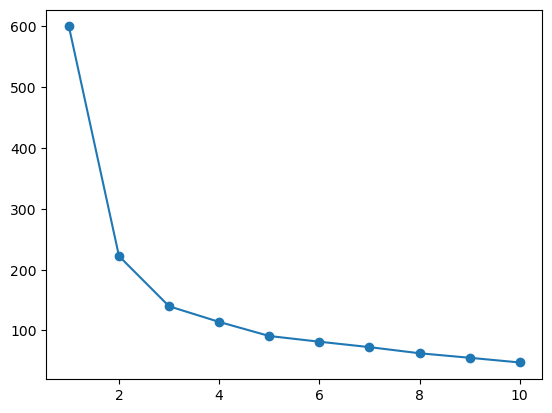

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.show()

Silhouette Score

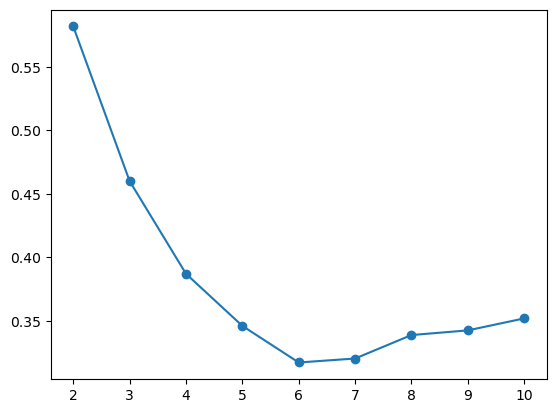

In [14]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

plt.plot(
    range(2, 11),
    scores,
    marker='o'
)
plt.show()

____________________________________________
PCA

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(150, 2)


In [19]:
print(pca.explained_variance_ratio_)
print(
    pca.explained_variance_ratio_.cumsum()
)

[0.72962445 0.22850762]
[0.72962445 0.95813207]


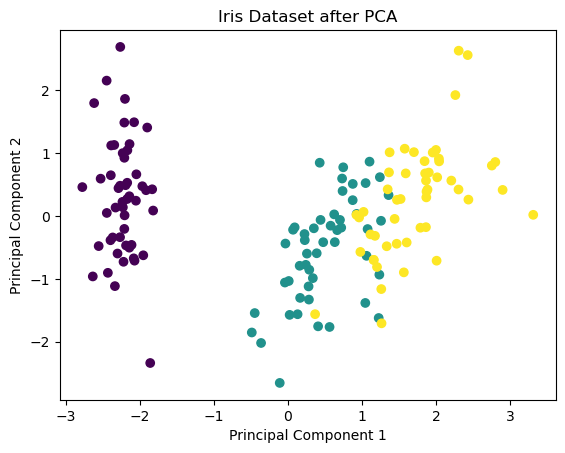

In [20]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset after PCA")
plt.show()

In [21]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_pca = kmeans_pca.fit_predict(X_pca)

print(labels_pca)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


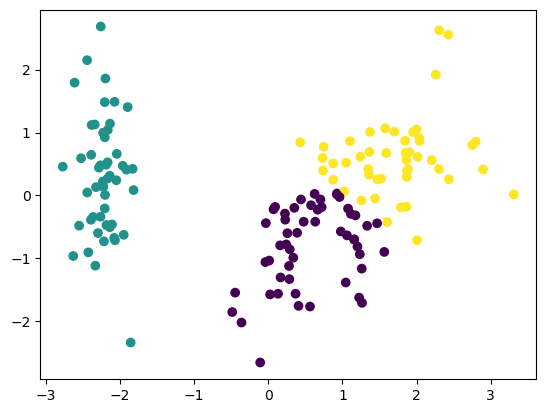

In [22]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_pca
)
plt.show()

In [23]:
score_org = silhouette_score(
    X_scaled, 
    kmeans_labels
)

score_pca = silhouette_score(
    X_pca,
    labels_pca
)

print('org: ', score_org)
print('pca: ', score_pca)

org:  0.45994823920518635
pca:  0.5091683341538228
